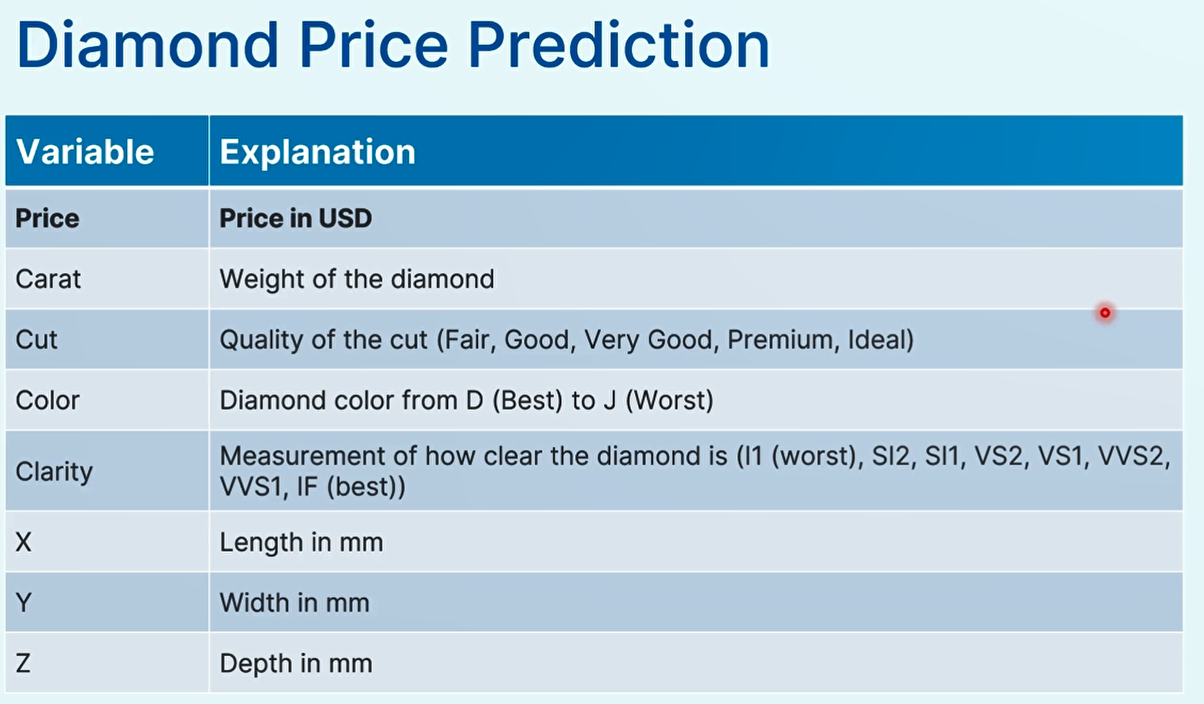

In [2]:
# Price is dependent variable
import pandas as pd
import numpy as np
import seaborn as sn
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [20]:
df = pd.read_csv("../data_analysis/sources/Diamond Price Prediction.csv")
df.head()

,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Carat(Weight of Daimond)  53940 non-null  float64
 1   Cut(Quality)              53940 non-null  str    
 2   Color                     53940 non-null  str    
 3   Clarity                   53940 non-null  str    
 4   Depth                     53940 non-null  float64
 5   Table                     53940 non-null  float64
 6   Price(in US dollars)      53940 non-null  int64  
 7   X(length)                 53940 non-null  float64
 8   Y(width)                  53940 non-null  float64
 9   Z(Depth)                  53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [11]:
df.shape

(53940, 10)

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Carat(Weight of Daimond),53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
Depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
Table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
Price(in US dollars),53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
X(length),53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
Y(width),53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
Z(Depth),53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


<Axes: ylabel='Carat(Weight of Daimond)'>

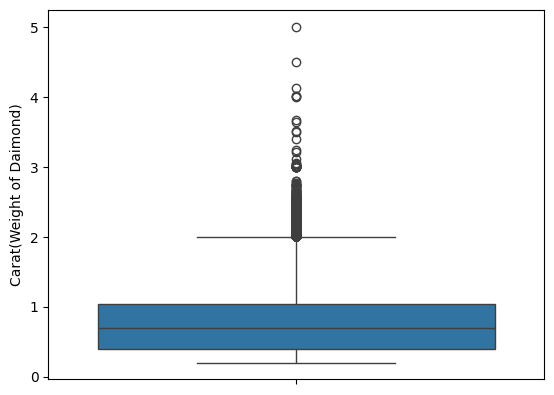

In [ ]:
#EDA
sn.boxplot(df["Carat(Weight of Daimond)"])

<Axes: xlabel='Carat(Weight of Daimond)', ylabel='Density'>

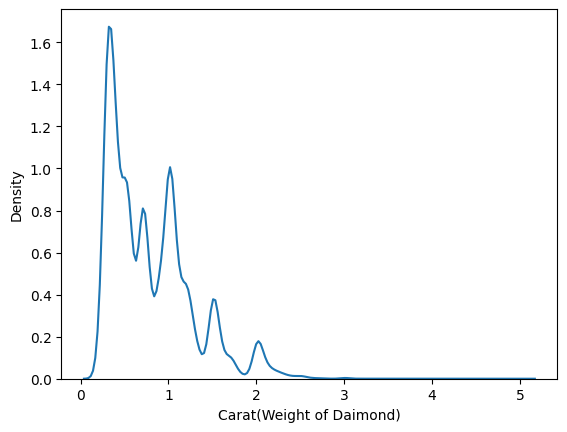

In [5]:
sn.kdeplot(df["Carat(Weight of Daimond)"])

In [6]:
df.columns

Index(['Carat(Weight of Daimond)', 'Cut(Quality)', 'Color', 'Clarity', 'Depth',
       'Table', 'Price(in US dollars)', 'X(length)', 'Y(width)', 'Z(Depth)'],
      dtype='str')

<Axes: ylabel='Price(in US dollars)'>

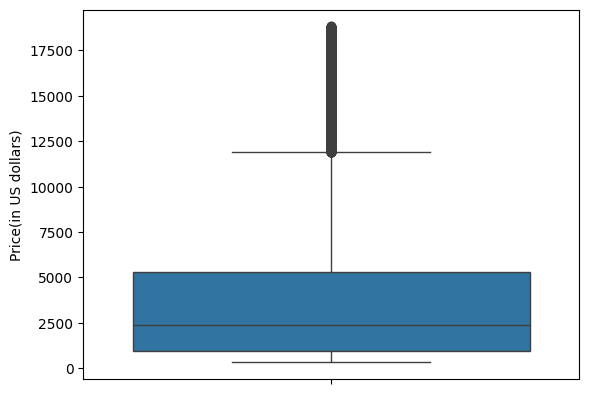

In [9]:
sn.boxplot(df['Price(in US dollars)'])

<Axes: xlabel='Price(in US dollars)', ylabel='Density'>

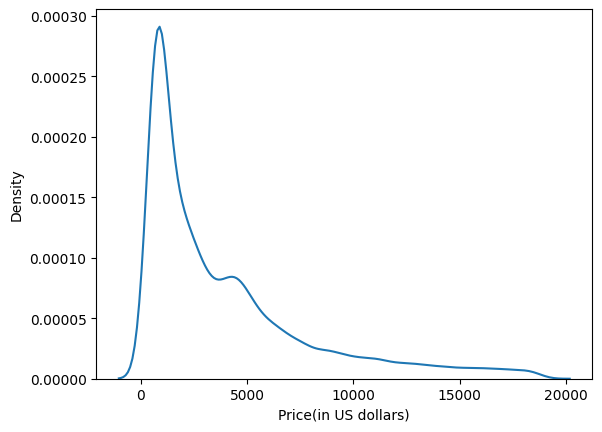

In [21]:
sn.kdeplot(df['Price(in US dollars)'])
# price is left skewed, it is not appropriate for linear regression

In [ ]:
#Renaming columns
df.columns

#! df.columns = ["full_name", "user_age"] #The number of new names must match the number of existing columns.
# *df.columns = df.columns.str.lower()
# *df.columns = df.columns.str.upper()
# *df.columns = df.columns.str.replace(" ", "_")
# *df.columns = df.columns.str.strip()
# *df.columns.values[2] = "new_column_name"
# *df = df.rename(columns={df.columns[2]: "new_column_name"})

df = df.rename(columns={'Carat(Weight of Daimond)': "Carat", "Cut(Quality)": "Cut", "Price(in US dollars)": "Price", "X(length)": "X", "Y(width)": "Y", "Z(Depth)": "Z"})
df

,Carat,Cut,Color,Clarity,Depth,Table,Price,X,Y,Z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [24]:
df.dtypes

Carat      float64
Cut            str
Color          str
Clarity        str
Depth      float64
Table      float64
Price        int64
X          float64
Y          float64
Z          float64
dtype: object

In [ ]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df["cut_encoded"] = le.fit_transform(df["Cut"])
# df


# ! Above encoding Categorical value by LabelEncode  

In [32]:
# Manually Encoding with map categorically variables

# mapping = {"Fair": 1, "Good": 2, "Very Good": 3, "Premium": 4, "Ideal": 5}
# df["cut_num"] = df["cut"].map(mapping)
# df[["price", "cut_num"]].corr()


In [ ]:
df.select_dtypes(exclude="number").columns #! Checking which columns are string/object with select_dtypes


Index(['Cut', 'Color', 'Clarity'], dtype='str')

In [ ]:
#!  df.select_dtypes(include="number").corr()  # This is for including only numeric values and excluding categorical values

In [31]:
# price vs other variables

df.corr(numeric_only=True)

,Carat,Depth,Table,Price,X,Y,Z,cut_encoded
Carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387,0.017124
Depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924,-0.194249
Table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929,0.150327
Price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249,0.039860
X,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772,0.022342
Y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006,0.027572
Z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000,0.002037
cut_encoded,0.017124,-0.194249,0.150327,0.039860,0.022342,0.027572,0.002037,1.000000


<Axes: >

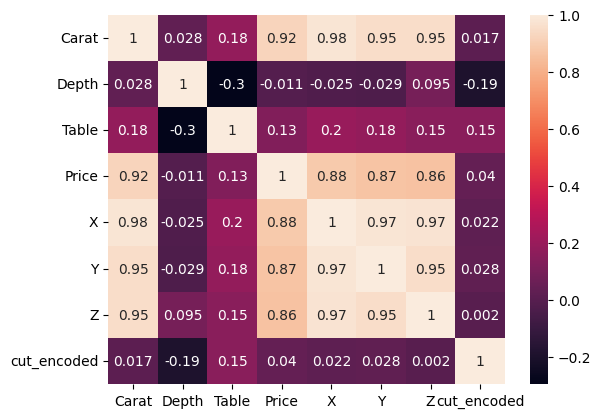

In [33]:
sn.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='Price', ylabel='Cut'>

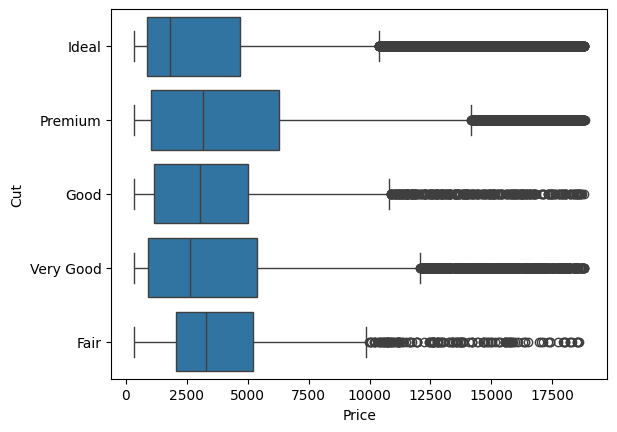

In [35]:
sn.boxplot(x=df.Price, y=df.Cut)

<Axes: xlabel='Price', ylabel='Clarity'>

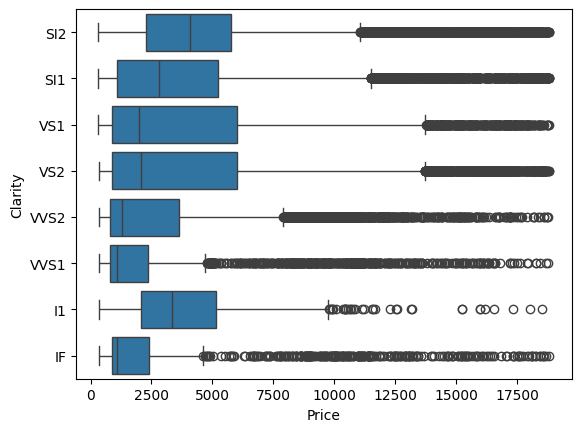

In [37]:
sn.boxplot(x=df.Price, y=df.Clarity)

<Axes: xlabel='Price', ylabel='Color'>

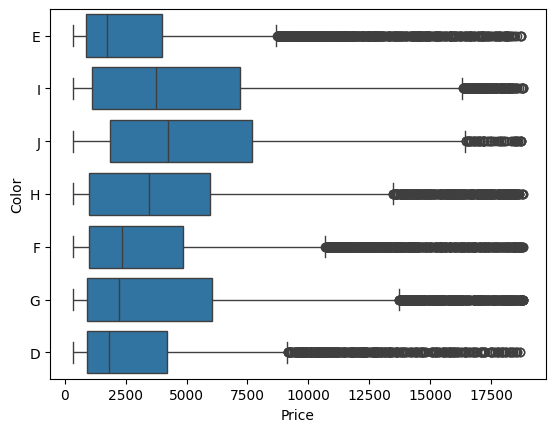

In [38]:
sn.boxplot(x=df.Price, y=df.Color)

<Axes: xlabel='Carat', ylabel='Price'>

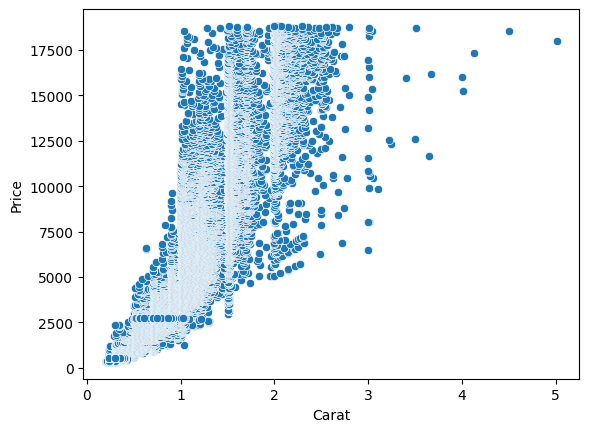

In [40]:
sn.scatterplot(x=df.Carat, y=df.Price)

<Axes: xlabel='Carat', ylabel='Price'>

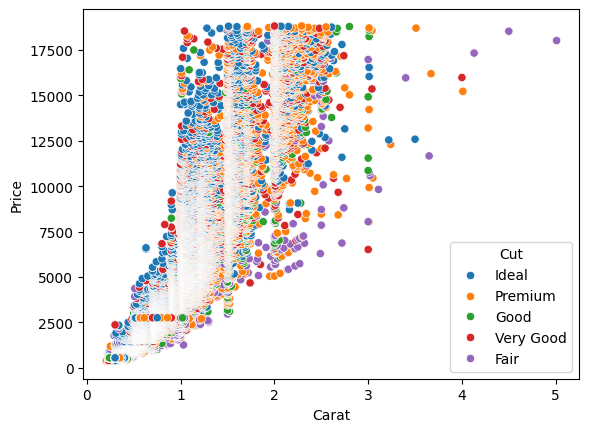

In [41]:
sn.scatterplot(x=df.Carat, y=df.Price, hue=df.Cut)

<Axes: xlabel='Carat', ylabel='Price'>

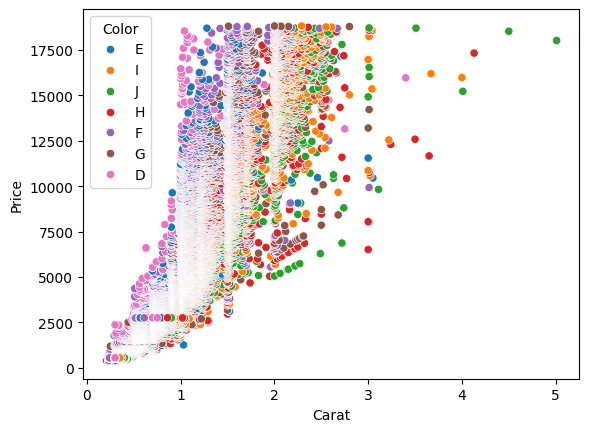

In [43]:
sn.scatterplot(x=df.Carat, y=df.Price, hue=df.Color)

<Axes: xlabel='Carat', ylabel='Price'>

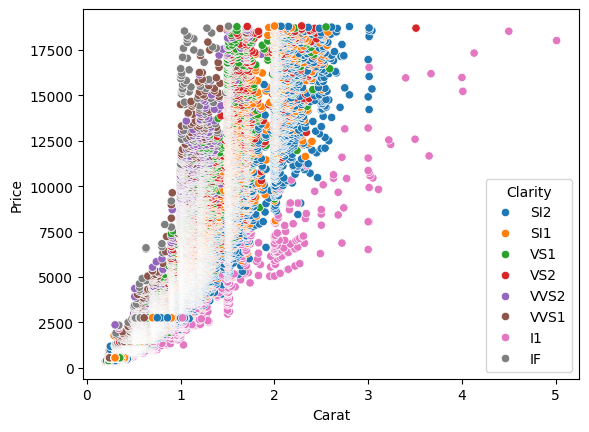

In [44]:
sn.scatterplot(x=df.Carat, y=df.Price, hue=df.Clarity)

In [46]:
# Model
df.columns

Index(['Carat', 'Cut', 'Color', 'Clarity', 'Depth', 'Table', 'Price', 'X', 'Y',
       'Z', 'cut_encoded'],
      dtype='str')

In [51]:
formula = 'Price ~ Carat + Cut + Color + Clarity + X + Y + Z'

In [53]:
lm = smf.ols(formula=formula, data=df).fit()

In [ ]:
lm.summary() 
# R-squared is from 0 to 1, since it is bigger than 0.5 it considered good

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                 2.931e+04
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:55:15   Log-Likelihood:            -4.5584e+05
No. Observations:               53940   AIC:                         9.117e+05
Df Residuals:                   53918   BIC:                         9.119e+05
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -3642.4909     91.784    -39.686      0.000   -3822.388   -3462.594
Cut[T.Good]        671.0546     33.078     20.287      0.000     606.222     735.887
Cut[T.Ideal]      1027.6687     30.293     33.925      0.000     968.295    1087.043
Cut[T.Premium]     907.8561     30.708     29.564      0.000     847.669     968.044
Cut[T.Very Good]   866.7948     30.860     28.088      0.000     806.309     927.281
Color[T.E]        -209.0244     17.928    -11.659      0.000    -244.164    -173.885
Color[T.F]        -273.6044     18.128    -15.093      0.000    -309.135    -238.074
Color[T.G]        -486.1915     17.743    -27.401      0.000    -520.968    -451.414
Color[T.H]        -986.0796     18.865    -52.269      0.000   -1023.056    -949.103
Color[T.I]       -1472.1112     21.200    -69.440      0.000   -1513.663   -1430.560
Color[T.J]       -2374.8829     26.180    -90.714      0.000   -2426.196   -2323.570
Clarity[T.IF]     5386.2861     51.045    105.520      0.000    5286.237    5486.335
Clarity[T.SI1]    3678.3986     43.712     84.152      0.000    3592.724    3764.074
Clarity[T.SI2]    2719.6723     43.889     61.967      0.000    2633.650    2805.695
Clarity[T.VS1]    4603.1027     44.601    103.207      0.000    4515.685    4690.520
Clarity[T.VS2]    4286.4549     43.920     97.597      0.000    4200.372    4372.538
Clarity[T.VVS1]   5039.0561     47.201    106.758      0.000    4946.543    5131.570
Clarity[T.VVS2]   4978.3146     45.905    108.449      0.000    4888.341    5068.288
Carat             1.113e+04     47.713    233.255      0.000     1.1e+04    1.12e+04
X                 -869.6540     30.618    -28.403      0.000    -929.666    -809.642
Y                   32.2006     19.296      1.669      0.095      -5.619      70.021
Z                 -227.6954     29.721     -7.661      0.000    -285.949    -169.442
==============================================================================
Omnibus:                    14526.359   Durbin-Watson:                   1.172
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           527551.029
Skew:                           0.613   Prob(JB):                         0.00
Kurtosis:                      18.272   Cond. No.                         236.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [59]:
pred = lm.predict(df)

<Axes: xlabel='Price', ylabel='None'>

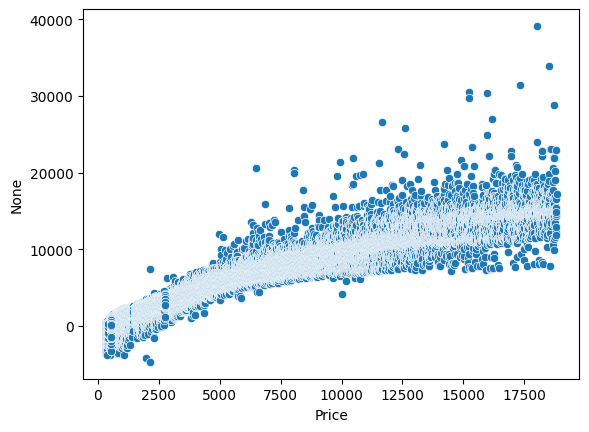

In [61]:
sn.scatterplot(x=df.Price, y=pred)

In [64]:
resid = pred - df.Price

<Axes: xlabel='Price', ylabel='None'>

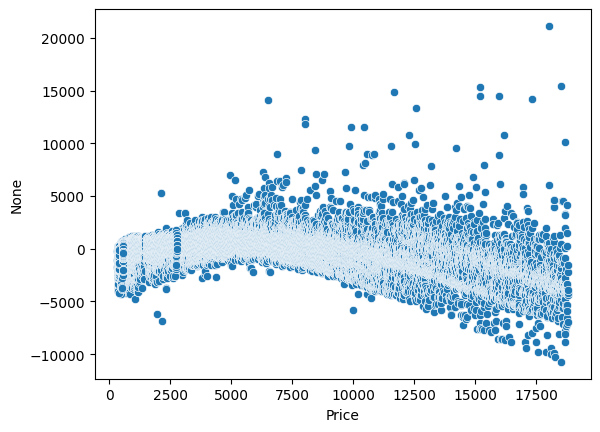

In [67]:
sn.scatterplot(x=df.Price, y=resid)

<Axes: ylabel='Density'>

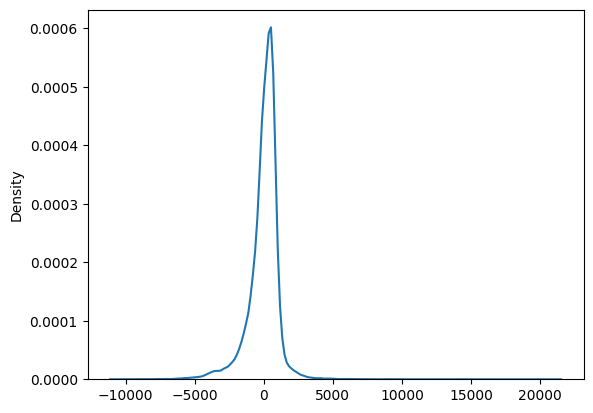

In [68]:
sn.kdeplot(resid)

In [115]:
df = pd.read_csv('../data_analysis/sources/Diamond Price Prediction.csv')
df

,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [116]:
df = df.rename(
    columns={
        "Carat(Weight of Daimond)": "Carat",
        "Cut(Quality)": "Cut",
        "Price(in US dollars)": "Price",
        "X(length)": "X",
        "Y(width)": "Y",
        "Z(Depth)": "Z",
    }
)
df


,Carat,Cut,Color,Clarity,Depth,Table,Price,X,Y,Z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


<Axes: xlabel='Price', ylabel='Density'>

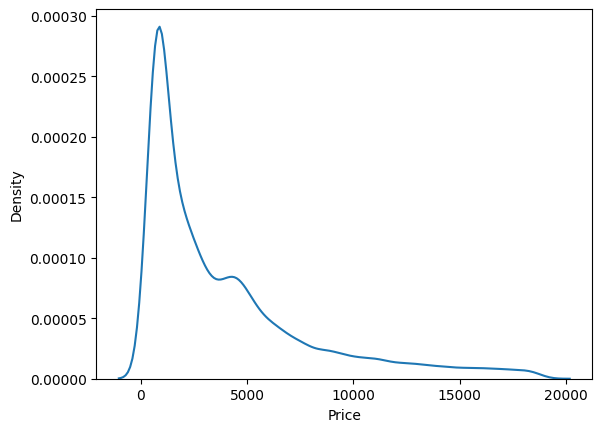

In [112]:
sn.kdeplot(df.Price)

<Axes: xlabel='Carat', ylabel='Density'>

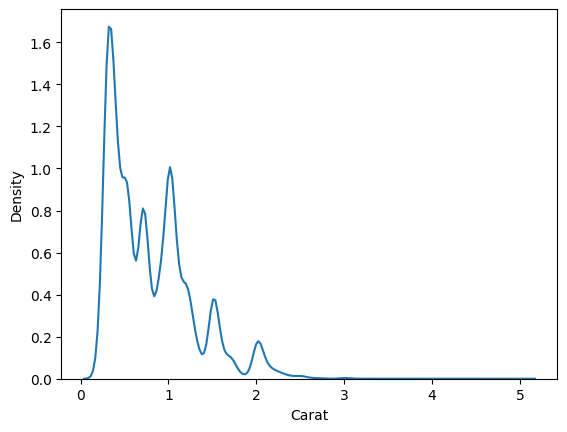

In [105]:
sn.kdeplot(df.Carat)

In [117]:
df["logprice"] = np.log(df.Price)
df.Carat = np.log(df.Carat)

<Axes: xlabel='Carat', ylabel='Density'>

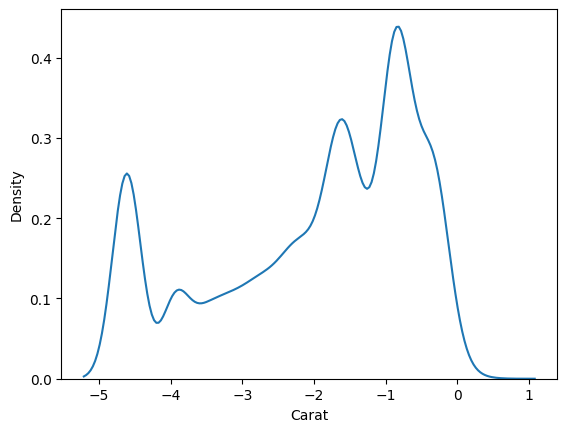

In [114]:
sn.kdeplot(df.Carat)

<Axes: xlabel='logprice', ylabel='Density'>

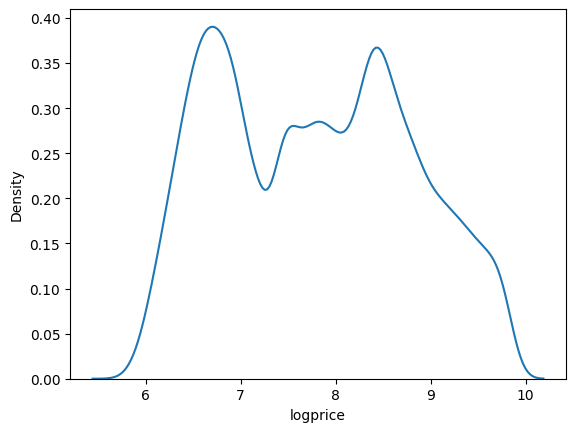

In [108]:
sn.kdeplot(df.logprice)

In [118]:
# if you have 0 value in your variable in np.log you have to add very small value like 0.1 before applying logs

df.select_dtypes(include='number').corr()

,Carat,Depth,Table,Price,X,Y,Z,logprice
Carat,1.000000,0.030434,0.191741,0.855526,0.990166,0.966495,0.969060,0.965914
Depth,0.030434,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924,0.000860
Table,0.191741,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929,0.158208
Price,0.855526,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249,0.895771
X,0.990166,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772,0.958010
Y,0.966495,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006,0.936173
Z,0.969060,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000,0.935218
logprice,0.965914,0.000860,0.158208,0.895771,0.958010,0.936173,0.935218,1.000000


<Axes: xlabel='Carat', ylabel='logprice'>

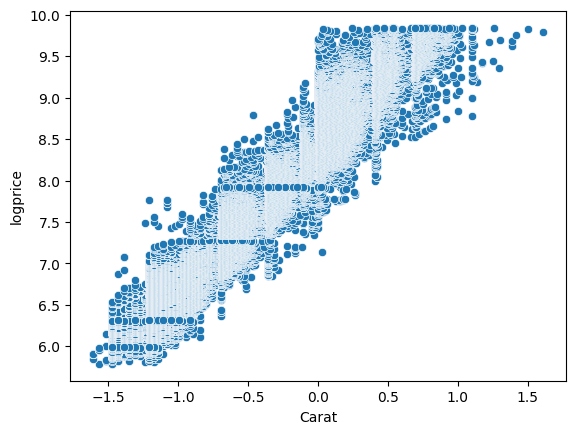

In [119]:
sn.scatterplot(x=df.Carat, y=df.logprice)

In [121]:
formula = 'logprice ~ Carat + Cut + Color + Clarity + X + Y + Z'

In [123]:
lm = smf.ols(formula=formula, data=df).fit()

In [124]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               logprice   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.457e+05
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:51:31   Log-Likelihood:                 32072.
No. Observations:               53940   AIC:                        -6.410e+04
Df Residuals:                   53918   BIC:                        -6.390e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            7.4967      0.026    293.146      0.000       7.447       7.547
Cut[T.Good]          0.0778      0.004     19.915      0.000       0.070       0.085
Cut[T.Ideal]         0.1556      0.004     43.275      0.000       0.149       0.163
Cut[T.Premium]       0.1324      0.004     36.221      0.000       0.125       0.140
Cut[T.Very Good]     0.1131      0.004     30.967      0.000       0.106       0.120
Color[T.E]          -0.0546      0.002    -25.826      0.000      -0.059      -0.050
Color[T.F]          -0.0944      0.002    -44.159      0.000      -0.099      -0.090
Color[T.G]          -0.1605      0.002    -76.701      0.000      -0.165      -0.156
Color[T.H]          -0.2524      0.002   -113.567      0.000      -0.257      -0.248
Color[T.I]          -0.3751      0.002   -150.423      0.000      -0.380      -0.370
Color[T.J]          -0.5143      0.003   -167.152      0.000      -0.520      -0.508
Clarity[T.IF]        1.1138      0.006    185.024      0.000       1.102       1.126
Clarity[T.SI1]       0.5961      0.005    115.885      0.000       0.586       0.606
Clarity[T.SI2]       0.4296      0.005     83.094      0.000       0.419       0.440
Clarity[T.VS1]       0.8146      0.005    155.172      0.000       0.804       0.825
Clarity[T.VS2]       0.7446      0.005    143.998      0.000       0.734       0.755
Clarity[T.VVS1]      1.0194      0.006    183.166      0.000       1.008       1.030
Clarity[T.VVS2]      0.9484      0.005    175.327      0.000       0.938       0.959
Carat                1.7771      0.007    238.107      0.000       1.763       1.792
X                    0.0513      0.004     11.419      0.000       0.043       0.060
Y                   -0.0020      0.002     -0.897      0.370      -0.007       0.002
Z                    0.0111      0.004      3.124      0.002       0.004       0.018
==============================================================================
Omnibus:                     3555.889   Durbin-Watson:                   1.268
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            15399.059
Skew:                           0.172   Prob(JB):                         0.00
Kurtosis:                       5.595   Cond. No.                         426.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [126]:
pred = lm.predict(df)

<Axes: xlabel='logprice', ylabel='None'>

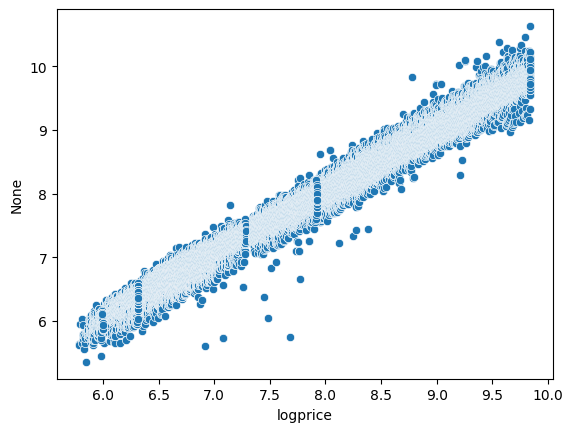

In [128]:
sn.scatterplot(x=df.logprice, y=pred)

In [129]:
resid = pred - df.logprice

<Axes: xlabel='logprice', ylabel='None'>

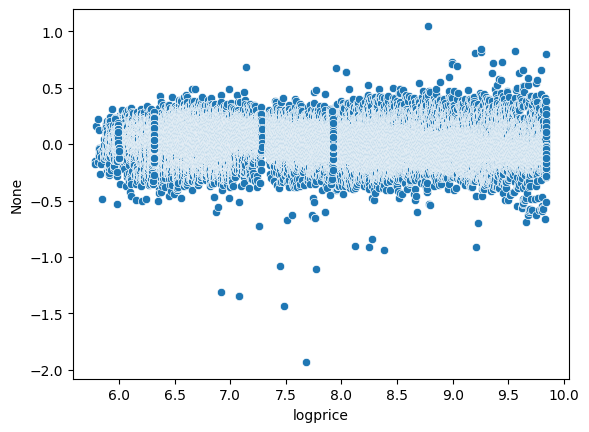

In [130]:
sn.scatterplot(x=df.logprice, y=resid)

<Axes: ylabel='Density'>

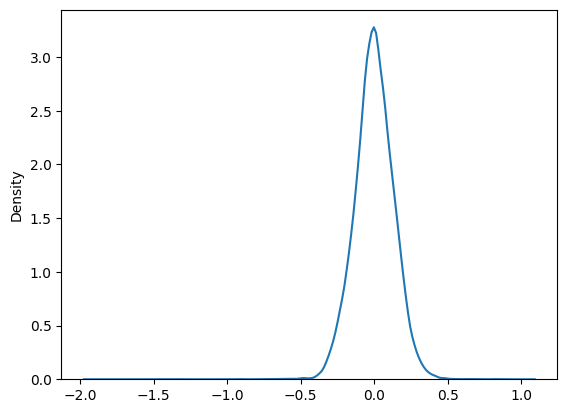

In [131]:
sn.kdeplot(resid)

In [133]:
# in this model we not predicting price, we predictiong logprice
np.exp(pred)

0         280.647327
1         274.385712
2         382.933084
3         417.744262
4         285.099003
            ...     
53935    2942.134316
53936    2716.710405
53937    2671.815551
53938    2651.669895
53939    2692.910409
Length: 53940, dtype: float64

<Axes: xlabel='Price', ylabel='None'>

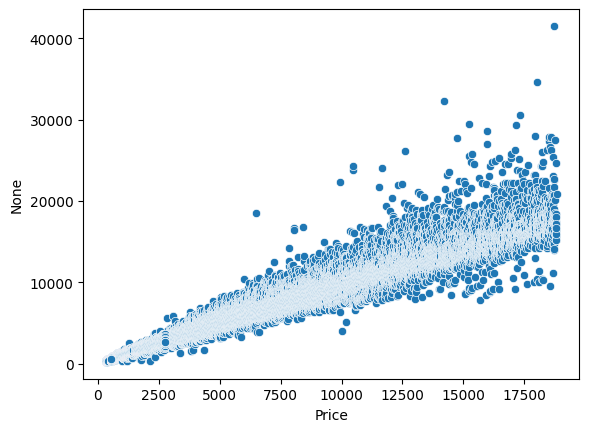

In [135]:
sn.scatterplot(x=df.Price, y=np.exp(pred))

In [141]:
# Method 2

df_new = pd.get_dummies(df, columns=['Cut', "Color", "Clarity"], drop_first=True) # this get_dummies convert Cut categorical to boolean
df_new

,Carat,Depth,Table,Price,X,Y,Z,logprice,Cut_Good,Cut_Ideal,...,Color_H,Color_I,Color_J,Clarity_IF,Clarity_SI1,Clarity_SI2,Clarity_VS1,Clarity_VS2,Clarity_VVS1,Clarity_VVS2
0,-1.469676,61.5,55.0,326,3.95,3.98,2.43,5.786897,False,True,...,False,False,False,False,False,True,False,False,False,False
1,-1.560648,59.8,61.0,326,3.89,3.84,2.31,5.786897,False,False,...,False,False,False,False,True,False,False,False,False,False
2,-1.469676,56.9,65.0,327,4.05,4.07,2.31,5.789960,True,False,...,False,False,False,False,False,False,True,False,False,False
3,-1.237874,62.4,58.0,334,4.20,4.23,2.63,5.811141,False,False,...,False,True,False,False,False,False,False,True,False,False
4,-1.171183,63.3,58.0,335,4.34,4.35,2.75,5.814131,True,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,-0.328504,60.8,57.0,2757,5.75,5.76,3.50,7.921898,False,True,...,False,False,False,False,True,False,False,False,False,False
53936,-0.328504,63.1,55.0,2757,5.69,5.75,3.61,7.921898,True,False,...,False,False,False,False,True,False,False,False,False,False
53937,-0.356675,62.8,60.0,2757,5.66,5.68,3.56,7.921898,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,-0.150823,61.0,58.0,2757,6.15,6.12,3.74,7.921898,False,False,...,True,False,False,False,False,True,False,False,False,False


In [144]:
X = df_new.drop(['logprice', 'Price'], axis=1) # axis=1 because this name for columns not for rows
y = df_new.logprice

In [147]:
x2 = sm.add_constant(X)
x2

,const,Carat,Depth,Table,X,Y,Z,Cut_Good,Cut_Ideal,Cut_Premium,...,Color_H,Color_I,Color_J,Clarity_IF,Clarity_SI1,Clarity_SI2,Clarity_VS1,Clarity_VS2,Clarity_VVS1,Clarity_VVS2
0,1.0,-1.469676,61.5,55.0,3.95,3.98,2.43,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,1.0,-1.560648,59.8,61.0,3.89,3.84,2.31,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,1.0,-1.469676,56.9,65.0,4.05,4.07,2.31,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,1.0,-1.237874,62.4,58.0,4.20,4.23,2.63,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,1.0,-1.171183,63.3,58.0,4.34,4.35,2.75,True,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,1.0,-0.328504,60.8,57.0,5.75,5.76,3.50,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53936,1.0,-0.328504,63.1,55.0,5.69,5.75,3.61,True,False,False,...,False,False,False,False,True,False,False,False,False,False
53937,1.0,-0.356675,62.8,60.0,5.66,5.68,3.56,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,1.0,-0.150823,61.0,58.0,6.15,6.12,3.74,False,False,True,...,True,False,False,False,False,True,False,False,False,False


In [153]:
y.dtype

dtype('float64')

In [156]:
x2.dtypes

const            float64
Carat            float64
Depth            float64
Table            float64
X                float64
Y                float64
Z                float64
Cut_Good            bool
Cut_Ideal           bool
Cut_Premium         bool
Cut_Very Good       bool
Color_E             bool
Color_F             bool
Color_G             bool
Color_H             bool
Color_I             bool
Color_J             bool
Clarity_IF          bool
Clarity_SI1         bool
Clarity_SI2         bool
Clarity_VS1         bool
Clarity_VS2         bool
Clarity_VVS1        bool
Clarity_VVS2        bool
dtype: object

In [157]:
x2.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   const          53940 non-null  float64
 1   Carat          53940 non-null  float64
 2   Depth          53940 non-null  float64
 3   Table          53940 non-null  float64
 4   X              53940 non-null  float64
 5   Y              53940 non-null  float64
 6   Z              53940 non-null  float64
 7   Cut_Good       53940 non-null  bool   
 8   Cut_Ideal      53940 non-null  bool   
 9   Cut_Premium    53940 non-null  bool   
 10  Cut_Very Good  53940 non-null  bool   
 11  Color_E        53940 non-null  bool   
 12  Color_F        53940 non-null  bool   
 13  Color_G        53940 non-null  bool   
 14  Color_H        53940 non-null  bool   
 15  Color_I        53940 non-null  bool   
 16  Color_J        53940 non-null  bool   
 17  Clarity_IF     53940 non-null  bool   
 18  Clarity_SI1    53

In [158]:
x2.select_dtypes(exclude="number").columns


Index(['Cut_Good', 'Cut_Ideal', 'Cut_Premium', 'Cut_Very Good', 'Color_E',
       'Color_F', 'Color_G', 'Color_H', 'Color_I', 'Color_J', 'Clarity_IF',
       'Clarity_SI1', 'Clarity_SI2', 'Clarity_VS1', 'Clarity_VS2',
       'Clarity_VVS1', 'Clarity_VVS2'],
      dtype='str')

In [160]:
x2 = pd.get_dummies(x2, drop_first=True)
x2

,const,Carat,Depth,Table,X,Y,Z,Cut_Good,Cut_Ideal,Cut_Premium,...,Color_H,Color_I,Color_J,Clarity_IF,Clarity_SI1,Clarity_SI2,Clarity_VS1,Clarity_VS2,Clarity_VVS1,Clarity_VVS2
0,1.0,-1.469676,61.5,55.0,3.95,3.98,2.43,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,1.0,-1.560648,59.8,61.0,3.89,3.84,2.31,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,1.0,-1.469676,56.9,65.0,4.05,4.07,2.31,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,1.0,-1.237874,62.4,58.0,4.20,4.23,2.63,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,1.0,-1.171183,63.3,58.0,4.34,4.35,2.75,True,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,1.0,-0.328504,60.8,57.0,5.75,5.76,3.50,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53936,1.0,-0.328504,63.1,55.0,5.69,5.75,3.61,True,False,False,...,False,False,False,False,True,False,False,False,False,False
53937,1.0,-0.356675,62.8,60.0,5.66,5.68,3.56,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,1.0,-0.150823,61.0,58.0,6.15,6.12,3.74,False,False,True,...,True,False,False,False,False,True,False,False,False,False


In [162]:
print(x2.dtypes.unique())


[dtype('float64') dtype('bool')]


In [163]:
model = sm.OLS(y, x2).fit()
model.summary()

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).